In [12]:
import sys
sys.path.append('../src')
from data_prep import prepare_full_dataset

df = prepare_full_dataset("C:\\Users\\Acer\\Documents\\GitHub\\energy-demand-forecast\\data\\demand_2025_hourly.csv")
df.head()

,value,datetime_utc,tz_time,geo_id,geo_name,hour,dayofweek,month,dayofyear,is_weekend,hour_sin,hour_cos,month_sin,month_cos,lag_24h,lag_168h,is_blackout
datetime,,,,,,,,,,,,,,,,,
2025-01-08 00:00:00+01:00,315876.0,2025-01-07T23:00:00Z,2025-01-07T23:00:00.000Z,8741,Península,0,2,1,8,0,0.000000,1.000000,0.5,0.866025,278464.0,275088.0,0
2025-01-08 01:00:00+01:00,290801.0,2025-01-08T00:00:00Z,2025-01-08T00:00:00.000Z,8741,Península,1,2,1,8,0,0.258819,0.965926,0.5,0.866025,257973.0,266231.0,0
2025-01-08 02:00:00+01:00,275867.0,2025-01-08T01:00:00Z,2025-01-08T01:00:00.000Z,8741,Península,2,2,1,8,0,0.500000,0.866025,0.5,0.866025,245482.0,251434.0,0
2025-01-08 03:00:00+01:00,269501.0,2025-01-08T02:00:00Z,2025-01-08T02:00:00.000Z,8741,Península,3,2,1,8,0,0.707107,0.707107,0.5,0.866025,241077.0,237297.0,0
2025-01-08 04:00:00+01:00,269468.0,2025-01-08T03:00:00Z,2025-01-08T03:00:00.000Z,8741,Península,4,2,1,8,0,0.866025,0.500000,0.5,0.866025,242624.0,227683.0,0


SARIMA

In [28]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error
import warnings
warnings.filterwarnings("ignore")

y_series = df['value']
is_blackout = df['is_blackout']
HORIZON = 168  

tscv = TimeSeriesSplit(n_splits=5)
results_sarima = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(y_series)):
    y_train = y_series.iloc[train_idx]
    # Només la primera setmana del bloc de test, no tot el bloc
    test_idx_short = test_idx[:HORIZON]
    y_test = y_series.iloc[test_idx_short]
    blackout_test = is_blackout.iloc[test_idx_short]
    
    print(f"Fold {fold+1}: entrenando con {len(y_train)} horas, prediciendo {len(y_test)} horas...")
    
    model_sarima = SARIMAX(y_train,
                            order=(1,1,1),
                            seasonal_order=(1,1,1,24),
                            enforce_stationarity=False,
                            enforce_invertibility=False)
    fitted = model_sarima.fit(disp=False)
    
    preds = fitted.forecast(steps=len(y_test))
    
    mask = (blackout_test == 0).values
    mape = mean_absolute_percentage_error(y_test[mask], preds[mask]) * 100
    rmse = root_mean_squared_error(y_test[mask], preds[mask])
    
    results_sarima.append({'fold': fold+1, 'MAPE': mape, 'RMSE': rmse})
    print(f"  MAPE={mape:.2f}%, RMSE={rmse:.0f}\n")

# Guarda els resultats de SARIMA (últim fold, 1 setmana) amb noms propis
preds_sarima_final = preds.copy()
y_test_sarima_final = y_test.copy()

results_sarima_df = pd.DataFrame(results_sarima)
print(f"\nMAPE medio SARIMA: {results_sarima_df['MAPE'].mean():.2f}%")
print(f"RMSE medio SARIMA: {results_sarima_df['RMSE'].mean():.0f}")

Fold 1: entrenando con 1432 horas, prediciendo 168 horas...
  MAPE=51.02%, RMSE=197161

Fold 2: entrenando con 2864 horas, prediciendo 168 horas...
  MAPE=19.43%, RMSE=64176

Fold 3: entrenando con 4296 horas, prediciendo 168 horas...
  MAPE=26.01%, RMSE=101620

Fold 4: entrenando con 5728 horas, prediciendo 168 horas...
  MAPE=17.72%, RMSE=64185

Fold 5: entrenando con 7160 horas, prediciendo 168 horas...
  MAPE=58.34%, RMSE=192612


MAPE medio SARIMA: 34.50%
RMSE medio SARIMA: 123951


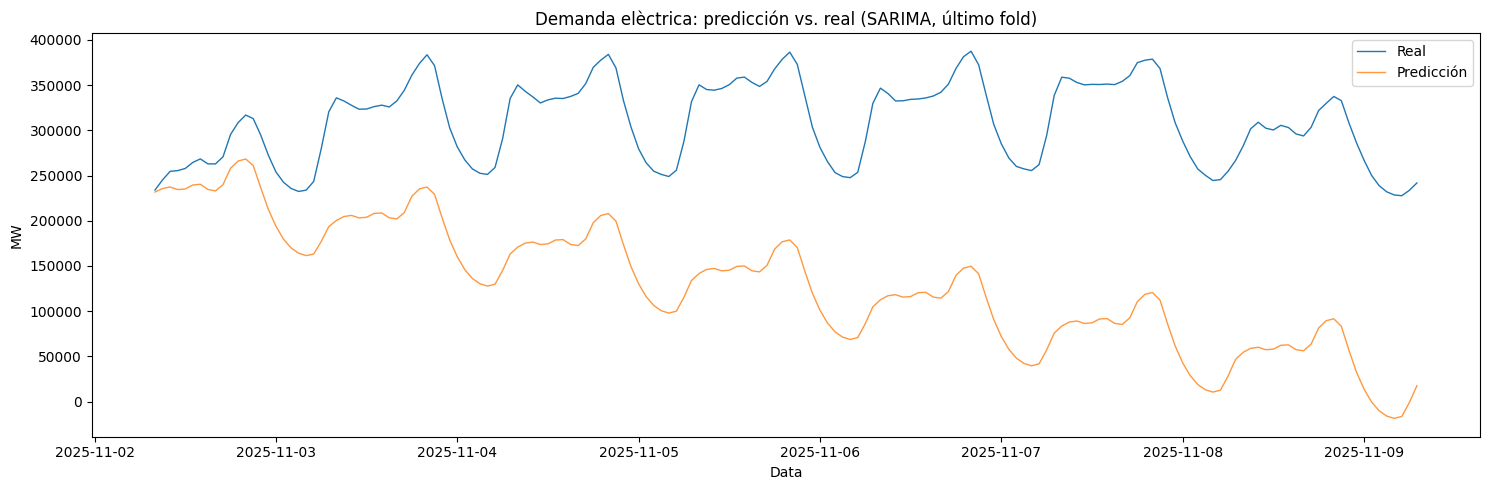

In [29]:
plt.figure(figsize=(15, 5))
plt.plot(y_test.index, y_test, label='Real', linewidth=1)
plt.plot(y_test.index, preds, label='Predicción', linewidth=1, alpha=0.8)
plt.title('Demanda elèctrica: predicción vs. real (SARIMA, último fold)')
plt.xlabel('Data')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/sarima_prediction_vs_real.png', dpi=150)
plt.show()

XGBoost

In [30]:
import pandas as pd

# Últim mes (desembre 2025) com a test, la resta com a train
train = df[df.index < "2025-12-01"]
test = df[df.index >= "2025-12-01"]

print(f"Train: {train.shape[0]} files ({train.index.min()} a {train.index.max()})")
print(f"Test: {test.shape[0]} files ({test.index.min()} a {test.index.max()})")

Train: 7848 files (2025-01-08 00:00:00+01:00 a 2025-11-30 23:00:00+01:00)
Test: 744 files (2025-12-01 00:00:00+01:00 a 2025-12-31 23:00:00+01:00)


In [ ]:
from xgboost import XGBRegressor

features = ['hour', 'dayofweek', 'month', 'is_weekend', 
            'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
            'lag_24h', 'lag_168h', 'is_blackout']

X_train, y_train = train[features], train['value']
X_test, y_test = test[features], test['value']

model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)



In [32]:
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error

mape = mean_absolute_percentage_error(y_test, preds) * 100
rmse = root_mean_squared_error(y_test, preds)

print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.0f} MW")

MAPE: 4.44%
RMSE: 22706 MW


In [37]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error
import pandas as pd

features = ['hour', 'dayofweek', 'month', 'is_weekend', 
            'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
            'lag_24h', 'lag_168h', 'is_blackout']

X = df[features]
y = df['value']

tscv = TimeSeriesSplit(n_splits=5)
results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


    print(f"Fold {fold+1}:")
    print(f"  Train: {X_train.index.min()} → {X_train.index.max()} ({len(X_train)} files)")
    print(f"  Test:  {X_test.index.min()} → {X_test.index.max()} ({len(X_test)} files)")
    
    
    model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    

    mask = (X_test['is_blackout'] == 0).values
    
    if X_test['is_blackout'].sum() > 0:
        print(f"  ⚠️ Fold {fold+1} incluye el día de la apagada ({X_test['is_blackout'].sum()} files excloses del càlcul)")
    
    mape = mean_absolute_percentage_error(y_test[mask], preds[mask]) * 100
    rmse = root_mean_squared_error(y_test[mask], preds[mask])
    
    results.append({'fold': fold+1, 'MAPE': mape, 'RMSE': rmse})
    print(f"Fold {fold+1}: MAPE={mape:.2f}%, RMSE={rmse:.0f}")

preds_xgb_final = preds.copy()
y_test_xgb_final = y_test.copy()

results_df = pd.DataFrame(results)
print(f"\nMAPE medio: {results_df['MAPE'].mean():.2f}%")
print(f"RMSE medio: {results_df['RMSE'].mean():.0f}")

Fold 1:
  Train: 2025-01-08 00:00:00+01:00 → 2025-03-08 15:00:00+01:00 (1432 files)
  Test:  2025-03-08 16:00:00+01:00 → 2025-05-07 08:00:00+02:00 (1432 files)
  ⚠️ Fold 1 incluye el día de la apagada (24 files excloses del càlcul)
Fold 1: MAPE=9.44%, RMSE=37495
Fold 2:
  Train: 2025-01-08 00:00:00+01:00 → 2025-05-07 08:00:00+02:00 (2864 files)
  Test:  2025-05-07 09:00:00+02:00 → 2025-07-06 00:00:00+02:00 (1432 files)
Fold 2: MAPE=5.95%, RMSE=25275
Fold 3:
  Train: 2025-01-08 00:00:00+01:00 → 2025-07-06 00:00:00+02:00 (4296 files)
  Test:  2025-07-06 01:00:00+02:00 → 2025-09-03 16:00:00+02:00 (1432 files)
Fold 3: MAPE=3.92%, RMSE=17175
Fold 4:
  Train: 2025-01-08 00:00:00+01:00 → 2025-09-03 16:00:00+02:00 (5728 files)
  Test:  2025-09-03 17:00:00+02:00 → 2025-11-02 07:00:00+01:00 (1432 files)
Fold 4: MAPE=3.03%, RMSE=12279
Fold 5:
  Train: 2025-01-08 00:00:00+01:00 → 2025-11-02 07:00:00+01:00 (7160 files)
  Test:  2025-11-02 08:00:00+01:00 → 2025-12-31 23:00:00+01:00 (1432 files)
Fold

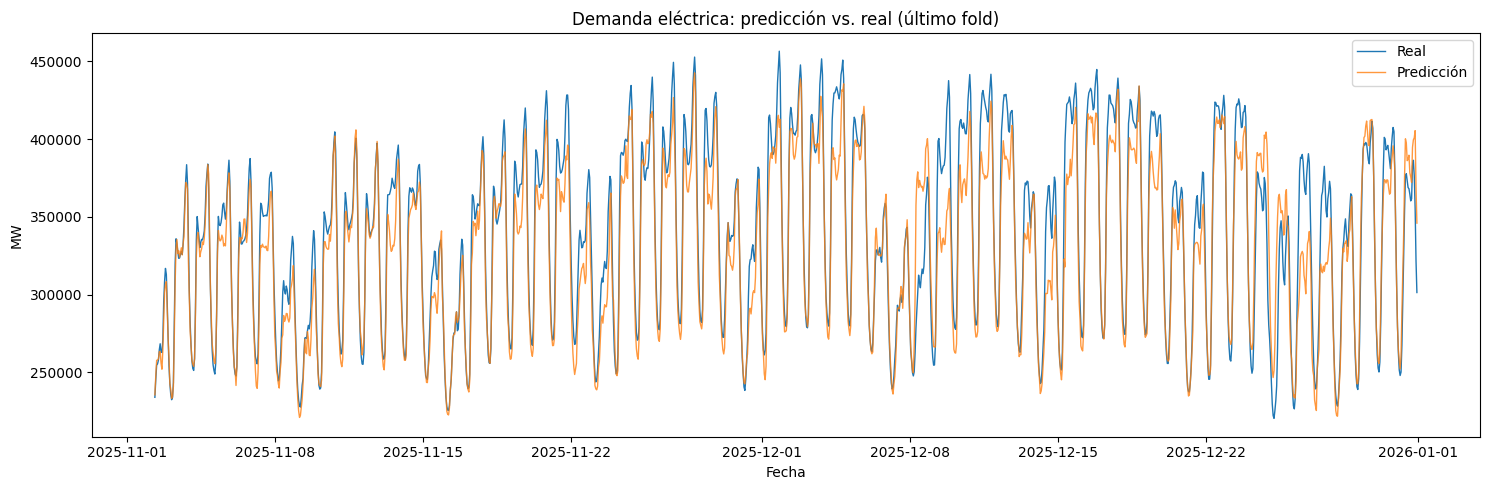

In [34]:
import matplotlib.pyplot as plt

# Agafem el fold 5 (últim), que ja tens de l'últim bucle
plt.figure(figsize=(15, 5))
plt.plot(X_test.index, y_test, label='Real', linewidth=1)
plt.plot(X_test.index, preds, label='Predicción', linewidth=1, alpha=0.8)
plt.title('Demanda eléctrica: predicción vs. real (último fold)')
plt.xlabel('Fecha')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/prediction_vs_real.png', dpi=150)
plt.show()

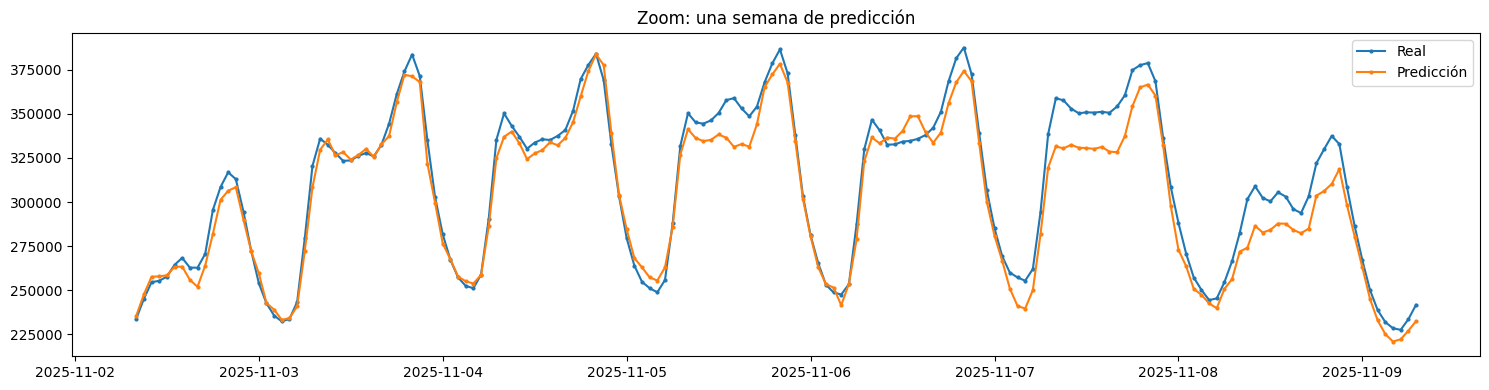

In [35]:
zoom = X_test.index[:24*7]  
plt.figure(figsize=(15, 4))
plt.plot(zoom, y_test.loc[zoom], label='Real', marker='o', markersize=2)
plt.plot(zoom, preds[:24*7], label='Predicción', marker='o', markersize=2)
plt.title('Zoom: una semana de predicción')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/prediction_zoom_week.png', dpi=150)
plt.show()

Gráfico comparativo

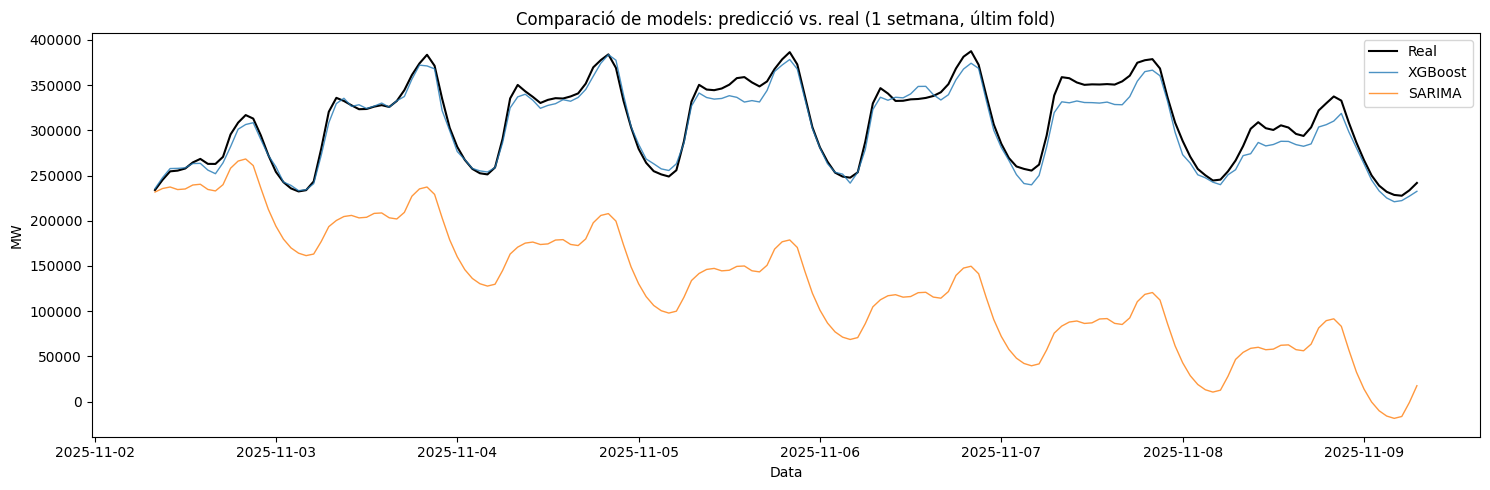

In [38]:
zoom_idx = y_test_sarima_final.index  # la setmana de SARIMA

plt.figure(figsize=(15, 5))
plt.plot(zoom_idx, y_test_xgb_final.loc[zoom_idx], label='Real', linewidth=1.5, color='black')
plt.plot(zoom_idx, preds_xgb_final[:len(zoom_idx)], label='XGBoost', linewidth=1, alpha=0.8)
plt.plot(zoom_idx, preds_sarima_final, label='SARIMA', linewidth=1, alpha=0.8)
plt.title('Comparació de models: predicció vs. real (1 setmana, últim fold)')
plt.xlabel('Data')
plt.ylabel('MW')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/comparison_xgb_sarima.png', dpi=150)
plt.show()